# `alignEpsilon` 收敛曲线测试

这个 Notebook 用来测试并可视化 `BaseAgent.alignEpsilon` 的收敛行为。

- 你可以在“参数设置”单元里手动改参数后重跑出图。
- 如果环境安装了 `ipywidgets`，还可以用滑条实时调参。

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt


def align_epsilon(step, max_eps=1.0, min_eps=0.05, decay_rate=2000, lam=1.0, power=2):
    """与 BaseAgent.alignEpsilon 一致的公式（去掉 sat/env 依赖）"""
    return min_eps + (max_eps - min_eps) * math.exp(-lam * step / (decay_rate * (power ** 2)))


def get_epsilon_curve(steps=5000, max_eps=1.0, min_eps=0.05, decay_rate=2000, lam=1.0, power=2):
    x = np.arange(steps + 1)
    y = np.array([align_epsilon(s, max_eps, min_eps, decay_rate, lam, power) for s in x])
    return x, y


def plot_curve(steps=5000, max_eps=1.0, min_eps=0.05, decay_rate=2000, lam=1.0, power=2):
    x, y = get_epsilon_curve(steps, max_eps, min_eps, decay_rate, lam, power)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, linewidth=2, label='epsilon(step)')
    plt.axhline(min_eps, linestyle='--', linewidth=1, label=f'min_eps={min_eps}')
    plt.title('Convergence Curve of alignEpsilon')
    plt.xlabel('step')
    plt.ylabel('epsilon')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'epsilon(0)={y[0]:.6f}, epsilon({steps})={y[-1]:.6f}')
    print(f'delta={y[0] - y[-1]:.6f}')

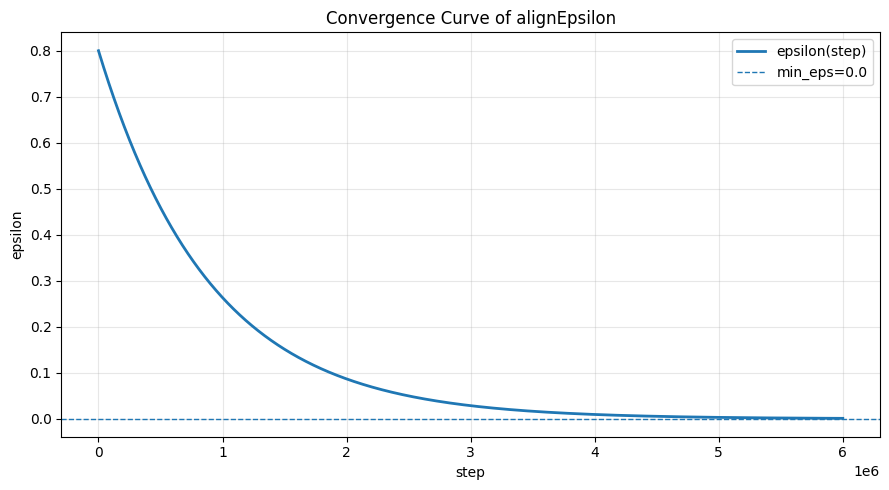

epsilon(0)=0.800000, epsilon(6000000)=0.001018
delta=0.798982


In [10]:
# 参数设置（手动修改这里即可）
steps = 6000000
max_eps = 0.8
min_eps = 0.00
decay_rate = 50
lam = 0.0005
power = 3

plot_curve(
    steps=steps,
    max_eps=max_eps,
    min_eps=min_eps,
    decay_rate=decay_rate,
    lam=lam,
    power=power,
)

这个公式：

$$
\text{queuePenalty} = - w_q \cdot \ln\left(1 + \frac{\text{queueTime}}{q_{ref}}\right)
$$

是在用**对数衰减**的方式，把 `queueTime` 映射成一个**负向惩罚项**。下面我拆开讲。

---

## 1. 各部分含义

### `queueTime`

排队时间，通常越大越差。

### `q_ref`

参考时间尺度，用来控制“多大的 queueTime 才算明显偏大”。

可以理解成一个**归一化参数**：

* 当 `queueTime = q_ref` 时，输入变成 `log1p(1)=ln(2)`
* 当 `queueTime << q_ref` 时，惩罚增长较慢
* 当 `queueTime >> q_ref` 时，惩罚继续增加，但增速越来越慢

### `wq`

权重，控制这个惩罚项的重要程度。

* 越大，排队时间对总分影响越强
* 越小，影响越弱

### `log1p(x)`

就是 `ln(1+x)`，相比直接写 `ln(1+x)`：

* 数值更稳定
* 当 `x` 很小时精度更好

---

## 2. 公式整体在表达什么

它表示：

> 排队时间越长，惩罚越大；
> 但惩罚不是线性增加，而是**前期敏感，后期变缓**。

因为对数函数的特点是：

* 一开始增长快
* 后面逐渐变平

所以这个公式适合表达一种策略：

> “短时间增加一点点排队，会明显变差；
> 但已经排了很久的人，再多排一点，边际恶化没那么夸张。”



✅ 队列惩罚函数测试通过
参数: wq=20.0, q_ref=0.005

样本点对比（单位: 秒）
t= 0.000 | new= -0.00000 | old=  0.00000
t= 0.001 | new= -3.64643 | old= -0.04610
t= 0.003 | new= -9.40007 | old= -0.13863
t= 0.005 | new=-13.86294 | old= -0.23159
t= 0.010 | new=-21.97225 | old= -0.46586
t= 0.020 | new=-32.18876 | old= -0.94257
t= 0.050 | new=-47.95791 | old= -2.44037


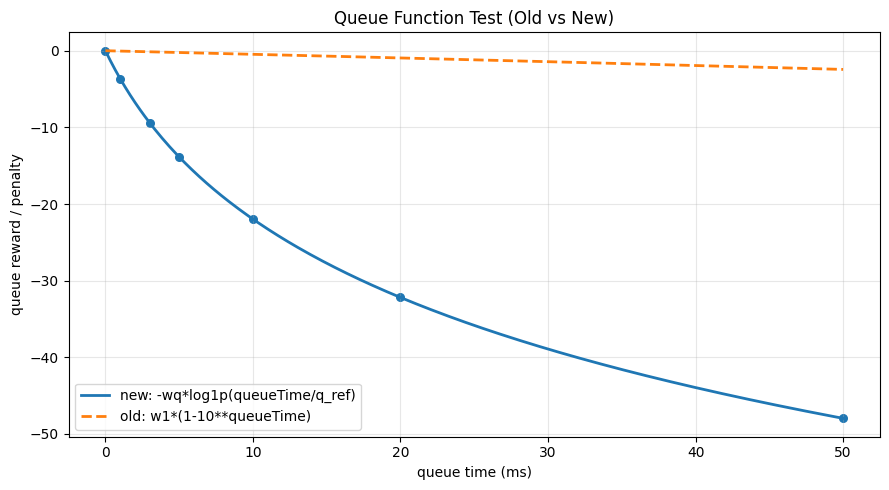

In [6]:
# 测试队列惩罚函数（新旧公式对比）
import math
import numpy as np
import matplotlib.pyplot as plt


def queue_penalty_log(queue_time, wq=2.0, q_ref=0.005):
    """建议公式: queuePenalty = -wq * log1p(queueTime / q_ref)"""
    queue_time = max(float(queue_time), 0.0)
    return -wq * math.log1p(queue_time / max(float(q_ref), 1e-9))


def queue_reward_old(queue_time, w1=2.0):
    """项目旧公式（Utils/utilsfunction.py:getQueueReward）"""
    queue_time = max(float(queue_time), 0.0)
    return w1 * (1 - 10 ** queue_time)


def test_queue_penalty(wq=2.0, q_ref=0.05):
    queue_times = np.array([0.0, 0.001, 0.003, 0.005, 0.01, 0.02, 0.05])  # 秒
    new_vals = np.array([queue_penalty_log(t, wq=wq, q_ref=q_ref) for t in queue_times])
    old_vals = np.array([queue_reward_old(t, w1=wq) for t in queue_times])

    # 基础性质测试
    assert abs(new_vals[0]) < 1e-12, "queue_time=0 时新公式应为 0"
    assert np.all(np.diff(new_vals) < 0), "新公式应随 queue_time 增大而单调递减（惩罚更重）"

    print("✅ 队列惩罚函数测试通过")
    print(f"参数: wq={wq}, q_ref={q_ref}")
    print("\n样本点对比（单位: 秒）")
    for t, nv, ov in zip(queue_times, new_vals, old_vals):
        print(f"t={t:>6.3f} | new={nv:>9.5f} | old={ov:>9.5f}")

    # 曲线可视化
    dense_t = np.linspace(0, 0.05, 300)
    dense_new = np.array([queue_penalty_log(t, wq=wq, q_ref=q_ref) for t in dense_t])
    dense_old = np.array([queue_reward_old(t, w1=wq) for t in dense_t])

    plt.figure(figsize=(9, 5))
    plt.plot(dense_t * 1000, dense_new, label="new: -wq*log1p(queueTime/q_ref)", linewidth=2)
    plt.plot(dense_t * 1000, dense_old, label="old: w1*(1-10**queueTime)", linewidth=2, linestyle="--")
    plt.scatter(queue_times * 1000, new_vals, s=30)
    plt.xlabel("queue time (ms)")
    plt.ylabel("queue reward / penalty")
    plt.title("Queue Function Test (Old vs New)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


test_queue_penalty(wq=20.0, q_ref=0.005)